In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, PReLU
from tensorflow.keras.optimizers import Adam, Nadam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import torch
import warnings
from pytorch_tabnet.tab_model import TabNetRegressor
from pytorch_tabnet.metrics import Metric
from sklearn.preprocessing import RobustScaler
import warnings 
warnings.filterwarnings("ignore")


plt.style.use('seaborn')

plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [5]:
try:
    import pytorch_tabnet
except ImportError:
    !pip install pytorch-tabnet
    !pip install torch==1.12.1+cu113 torchvision==0.13.1+cu113 torchaudio==0.12.1 --extra-index-url https://download.pytorch.org/whl/cu113
    from pytorch_tabnet.tab_model import TabNetRegressor

In [7]:
train = pd.read_csv("/kaggle/input/molecular/train.csv")
test = pd.read_csv("/kaggle/input/molecular/test.csv")

# Feature engineering
features_to_drop = ["Batch_ID", "T80", "Smiles"]
X = train.drop(features_to_drop, axis=1)
y = np.log1p(train["T80"])  # Log transformation
X_test = test.drop(features_to_drop, axis=1)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Advanced feature scaling
scaler = RobustScaler(quantile_range=(5, 95))
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to float32 for DL models
X_train_scaled = X_train_scaled.astype(np.float32)
X_val_scaled = X_val_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)
y_train = y_train.values.astype(np.float32)
y_val = y_val.values.astype(np.float32)

In [8]:
models = {
    "XGBoost": XGBRegressor(random_state=42, n_estimators=500, learning_rate=0.05, max_depth=7),
    "GBM": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42),
    "Ridge": Ridge(alpha=0.5)
}

# Train and evaluate ML models
ml_results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    ml_results[name] = rmse
    print(f"{name} Validation RMSE: {rmse:.4f}\n")

#%% [markdown]
### 3. Advanced Deep Learning Models
#%%

#%% [code]
# 3.1 Self-Normalizing Neural Network (SNN)
print("Training Self-Normalizing Neural Network...")

snn_model = Sequential([
    Dense(512, kernel_initializer='lecun_normal', kernel_regularizer=l2(1e-4)),
    PReLU(),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(256, kernel_initializer='lecun_normal', kernel_regularizer=l2(1e-4)),
    PReLU(),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(128, kernel_initializer='lecun_normal', kernel_regularizer=l2(1e-4)),
    PReLU(),
    BatchNormalization(),
    
    Dense(1)
])

optimizer = Nadam(learning_rate=1e-3)
snn_model.compile(optimizer=optimizer, loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])

callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=5)
]

snn_history = snn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

snn_preds = snn_model.predict(X_val_scaled).flatten()
snn_rmse = np.sqrt(mean_squared_error(y_val, snn_preds))
ml_results["SNN"] = snn_rmse
print(f"SNN Validation RMSE: {snn_rmse:.4f}\n")

Training XGBoost...
XGBoost Validation RMSE: 0.7095

Training GBM...
GBM Validation RMSE: 0.7902

Training Random Forest...
Random Forest Validation RMSE: 0.7287

Training Ridge...
Ridge Validation RMSE: 1.2348

Training Self-Normalizing Neural Network...
Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 10.5304 - root_mean_squared_error: 3.2312 - val_loss: 6.5465 - val_root_mean_squared_error: 2.5410 - learning_rate: 0.0010
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 8.7591 - root_mean_squared_error: 2.9444 - val_loss: 6.7127 - val_root_mean_squared_error: 2.5735 - learning_rate: 0.0010
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 8.8174 - root_mean_squared_error: 2.9543 - val_loss: 6.6825 - val_root_mean_squared_error: 2.5676 - learning_rate: 0.0010
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 8.1541 - root_mean_squared_error: 2.8398 - val_loss: 6.5263 - val_root_mean_squared_error: 2.5370 - learning_rate: 0.0010
Epoch 5/200
1/1 ━━━━━━━━━

In [9]:
try:
    print("Training TabNet with Advanced Configuration...")
    
    class RMSE(Metric):
        def __init__(self):
            self._name = "rmse"
            self._maximize = False

        def __call__(self, y_true, y_pred):
            return np.sqrt(np.mean((y_true - y_pred)**2))

    tabnet_params = {
        'n_d': 64,
        'n_a': 64,
        'n_steps': 6,
        'gamma': 1.5,
        'lambda_sparse': 1e-4,
        'optimizer_fn': torch.optim.AdamW,
        'optimizer_params': {'lr': 2e-2, 'weight_decay': 1e-5},
        'mask_type': 'entmax',
        'scheduler_params': {'step_size': 10, 'gamma': 0.9},
        'scheduler_fn': torch.optim.lr_scheduler.StepLR,
        'device_name': 'cuda' if torch.cuda.is_available() else 'cpu'
    }

    tabnet_model = TabNetRegressor(**tabnet_params)
    
    tabnet_model.fit(
        X_train_scaled, y_train.reshape(-1, 1),
        eval_set=[(X_val_scaled, y_val.reshape(-1, 1))],
        eval_metric=[RMSE],
        max_epochs=100,
        patience=15,
        batch_size=1024,
        virtual_batch_size=256,
        num_workers=0,
        drop_last=False,
        augmentations=None
    )

    tabnet_preds = tabnet_model.predict(X_val_scaled).flatten()
    tabnet_rmse = np.sqrt(mean_squared_error(y_val, tabnet_preds))
    ml_results["TabNet"] = tabnet_rmse
    print(f"TabNet Validation RMSE: {tabnet_rmse:.4f}\n")
except Exception as e:
    print(f"TabNet failed to run: {str(e)}")
    ml_results["TabNet"] = np.nan

#%% [code]
# 3.3 Feature Tokenizer Transformer (FT-Transformer inspired)
print("Training Transformer-style Model...")

def create_ft_transformer(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    
    # Feature embedding
    x = Dense(128, activation=None)(inputs)
    x = BatchNormalization()(x)
    x = PReLU()(x)
    x = Dropout(0.2)(x)
    
    # Transformer-like processing
    for _ in range(3):
        # Self-attention would go here in full FT-Transformer
        # Simplified version with dense layers
        x_res = x
        x = Dense(256, activation=None)(x)
        x = BatchNormalization()(x)
        x = PReLU()(x)
        x = Dropout(0.3)(x)
        x = Dense(128, activation=None)(x)
        x = BatchNormalization()(x)
        x = PReLU()(x)
        x = Dropout(0.2)(x)
        x = tf.keras.layers.Add()([x, x_res])
    
    # Output
    x = Dense(64, activation=None)(x)
    x = BatchNormalization()(x)
    x = PReLU()(x)
    outputs = Dense(1)(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

ft_model = create_ft_transformer(X_train_scaled.shape[1])
ft_model.compile(optimizer=Adam(learning_rate=3e-4), loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])

ft_history = ft_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

ft_preds = ft_model.predict(X_val_scaled).flatten()
ft_rmse = np.sqrt(mean_squared_error(y_val, ft_preds))
ml_results["FT-Transformer"] = ft_rmse
print(f"FT-Transformer Validation RMSE: {ft_rmse:.4f}\n")


Training TabNet with Advanced Configuration...
TabNet failed to run: No module named 'torch._dynamo'
Training Transformer-style Model...
Epoch 1/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 7.8841 - root_mean_squared_error: 2.8079 - val_loss: 6.2989 - val_root_mean_squared_error: 2.5098 - learning_rate: 3.0000e-04
Epoch 2/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 8.3552 - root_mean_squared_error: 2.8905 - val_loss: 6.5591 - val_root_mean_squared_error: 2.5611 - learning_rate: 3.0000e-04
Epoch 3/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 8.3056 - root_mean_squared_error: 2.8819 - val_loss: 6.8068 - val_root_mean_squared_error: 2.6090 - learning_rate: 3.0000e-04
Epoch 4/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 7.8441 - root_mean_squared_error: 2.8007 - val_loss: 6.9980 - val_root_mean_squared_error: 2.6454 - learning_rate: 3.0000e-04
Epoch 5/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 7.3854 - root_mean_squared_error: 2.7176 - val_loss: 7.1580 - val_root_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


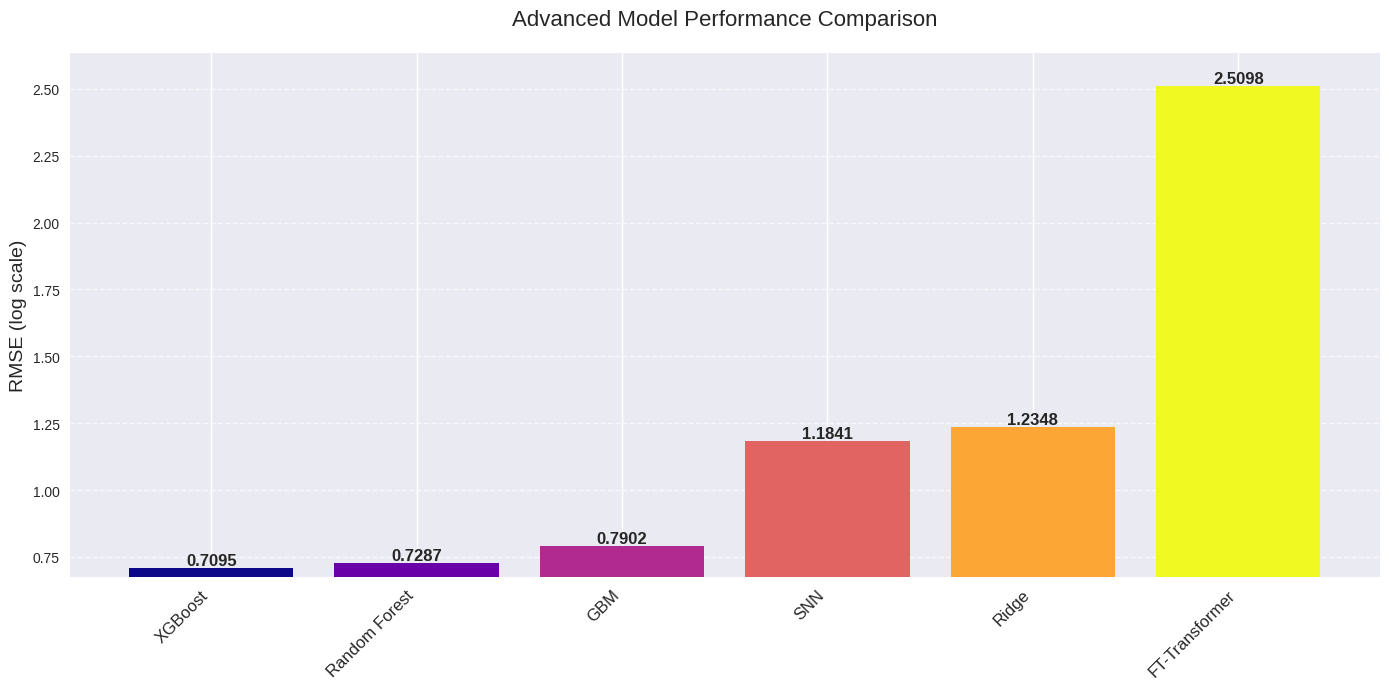

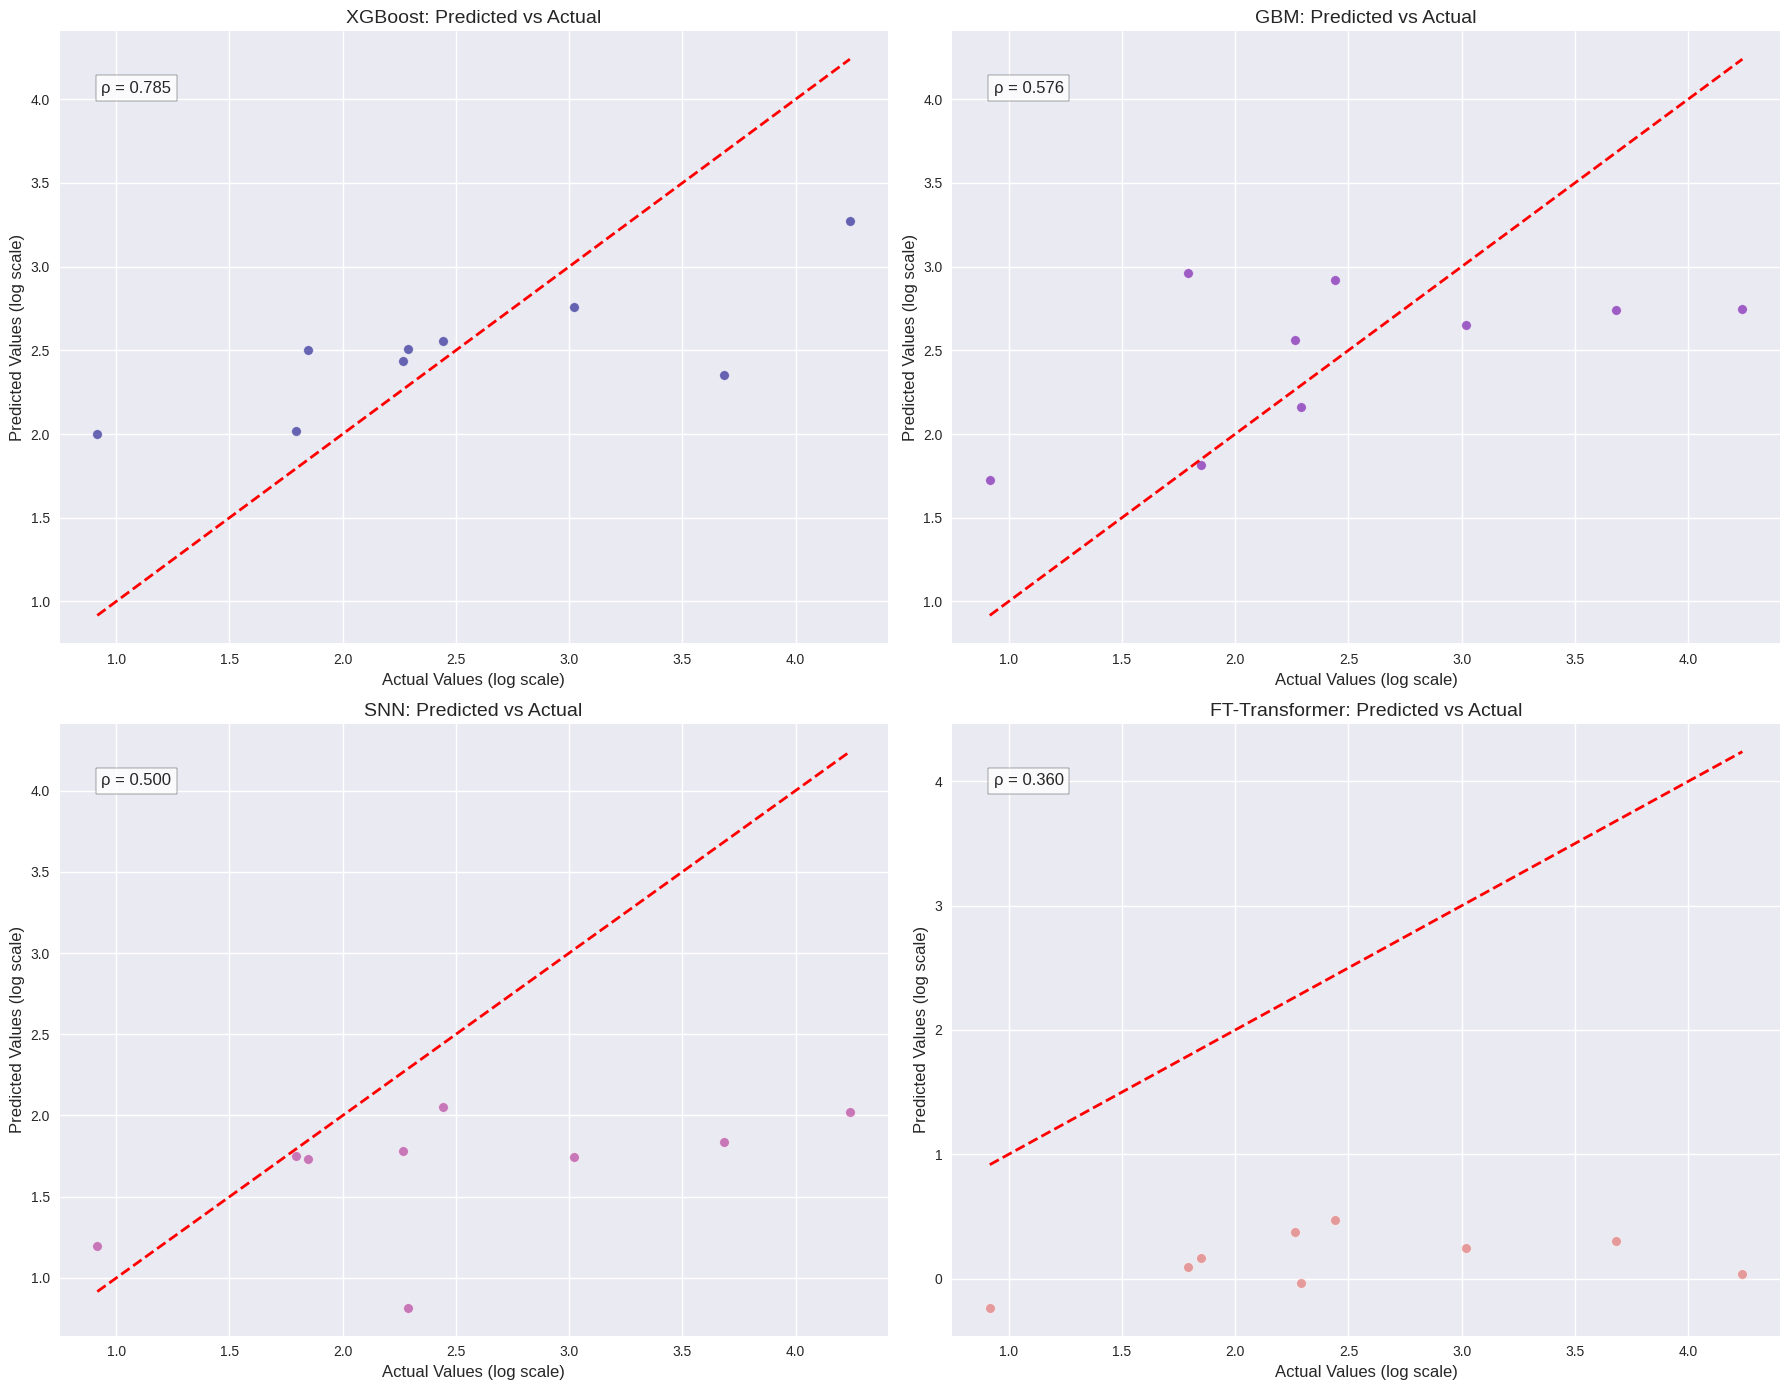

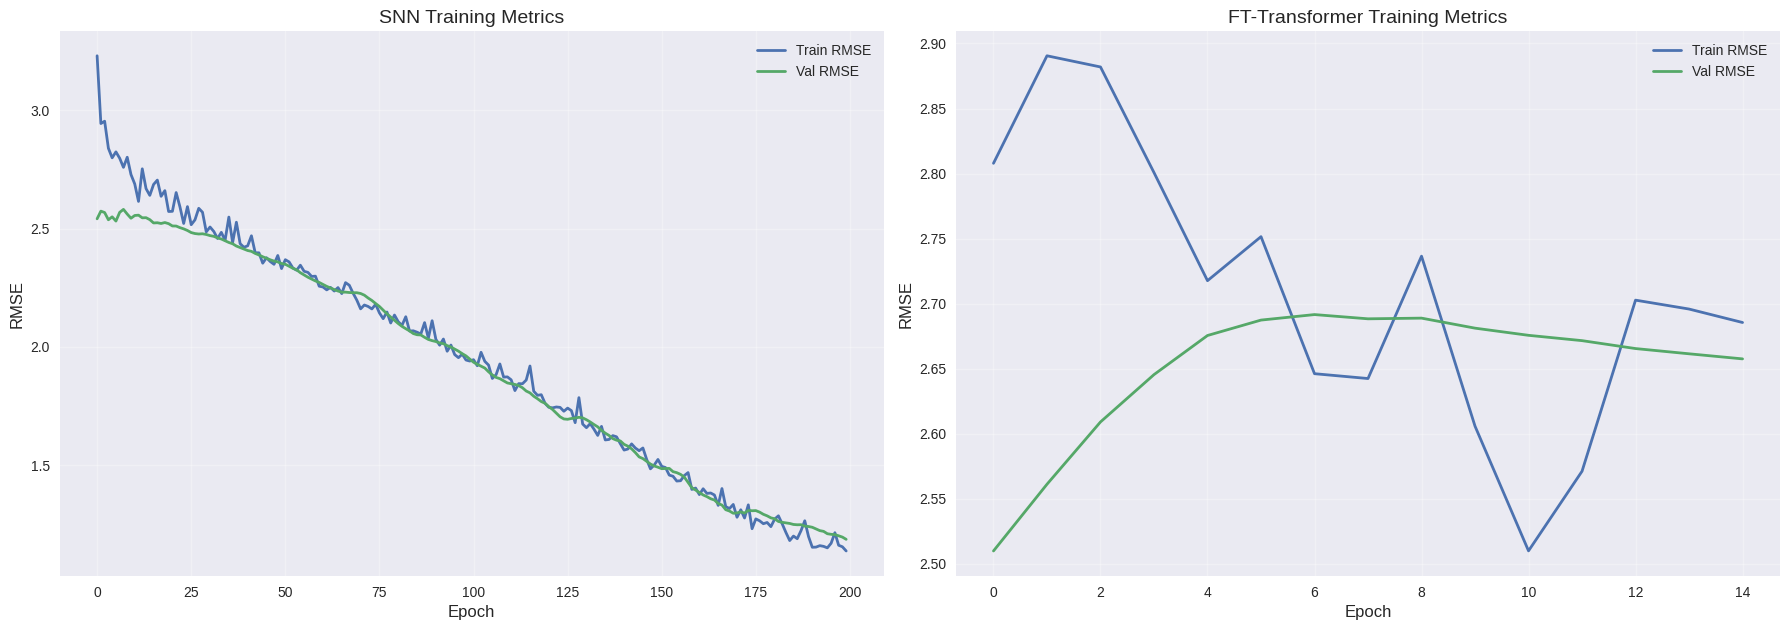

Saved XGBoost submission file
Saved GBM submission file
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Saved SNN submission file
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Saved FT-Transformer submission file


In [10]:
results = {
    'XGBoost': models['XGBoost'].predict(X_val_scaled),
    'GBM': models['GBM'].predict(X_val_scaled),
    'SNN': snn_model.predict(X_val_scaled).flatten(),
    'FT-Transformer': ft_model.predict(X_val_scaled).flatten()
}

if 'TabNet' in ml_results and not np.isnan(ml_results['TabNet']):
    results['TabNet'] = tabnet_model.predict(X_val_scaled).flatten()

#%% [code]
# RMSE Comparison
plt.figure(figsize=(14, 7))
valid_models = {k: v for k, v in ml_results.items() if not np.isnan(v)}
models_sorted = sorted(valid_models.items(), key=lambda x: x[1])

models_list = [x[0] for x in models_sorted]
values_list = [x[1] for x in models_sorted]

colors = plt.cm.plasma(np.linspace(0, 1, len(models_list)))
bars = plt.bar(models_list, values_list, color=colors)
plt.title('Advanced Model Performance Comparison', fontsize=16, pad=20)
plt.ylabel('RMSE (log scale)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylim(min(values_list)*0.95, max(values_list)*1.05)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#%% [code]
# Prediction vs Actual Plots
plt.figure(figsize=(18, 14))

for i, (model, preds) in enumerate(results.items(), 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(x=y_val, y=preds, alpha=0.6, color=colors[i-1])
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', linewidth=2)
    plt.title(f'{model}: Predicted vs Actual', fontsize=14)
    plt.xlabel('Actual Values (log scale)', fontsize=12)
    plt.ylabel('Predicted Values (log scale)', fontsize=12)
    
    # Add correlation coefficient
    r = np.corrcoef(y_val, preds)[0,1]
    plt.text(0.05, 0.9, f'ρ = {r:.3f}', transform=plt.gca().transAxes,
             fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

#%% [code]
# Training Curves Comparison
plt.figure(figsize=(18, 12))

# SNN Training
plt.subplot(2, 2, 1)
plt.plot(snn_history.history['root_mean_squared_error'], label='Train RMSE', linewidth=2)
plt.plot(snn_history.history['val_root_mean_squared_error'], label='Val RMSE', linewidth=2)
plt.title('SNN Training Metrics', fontsize=14)
plt.ylabel('RMSE', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

# FT-Transformer Training
plt.subplot(2, 2, 2)
plt.plot(ft_history.history['root_mean_squared_error'], label='Train RMSE', linewidth=2)
plt.plot(ft_history.history['val_root_mean_squared_error'], label='Val RMSE', linewidth=2)
plt.title('FT-Transformer Training Metrics', fontsize=14)
plt.ylabel('RMSE', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

# TabNet Training (if available)
if 'TabNet' in results:
    plt.subplot(2, 2, 3)
    plt.plot(tabnet_model.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(tabnet_model.history['val_loss'], label='Val Loss', linewidth=2)
    plt.title('TabNet Training Loss', fontsize=14)
    plt.ylabel('Loss', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#%% [markdown]
### 5. Generate Final Predictions
#%%

# Create submissions
for model_name in results.keys():
    try:
        if model_name in models:
            preds = np.expm1(models[model_name].predict(X_test_scaled))
        elif model_name == 'SNN':
            preds = np.expm1(snn_model.predict(X_test_scaled).flatten())
        elif model_name == 'FT-Transformer':
            preds = np.expm1(ft_model.predict(X_test_scaled).flatten())
        elif model_name == 'TabNet':
            preds = np.expm1(tabnet_model.predict(X_test_scaled).flatten())
        
        submission = test[['Batch_ID']].copy()
        submission['T80'] = preds
        submission.to_csv(f"advanced_{model_name.lower().replace(' ', '_')}_submission.csv", index=False)
        print(f"Saved {model_name} submission file")
    except Exception as e:
        print(f"Failed to generate predictions for {model_name}: {str(e)}")

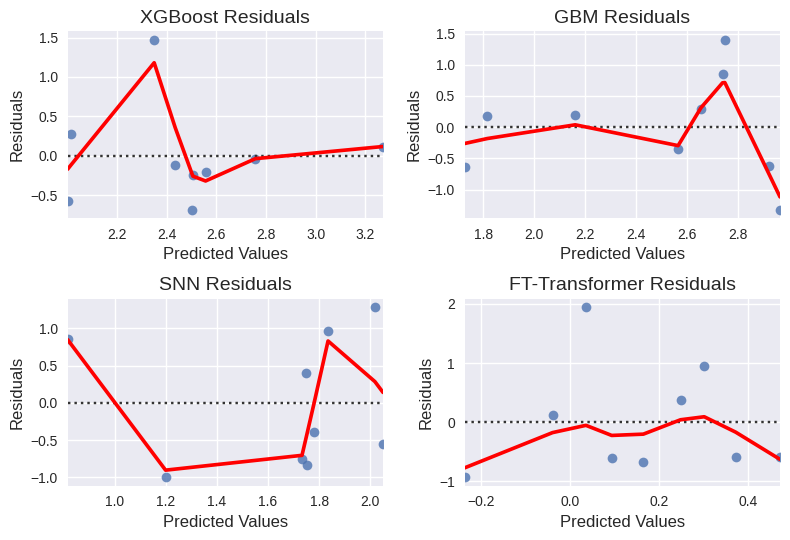

AttributeError: 'TabNetRegressor' object has no attribute 'history'

<Figure size 1800x600 with 0 Axes>

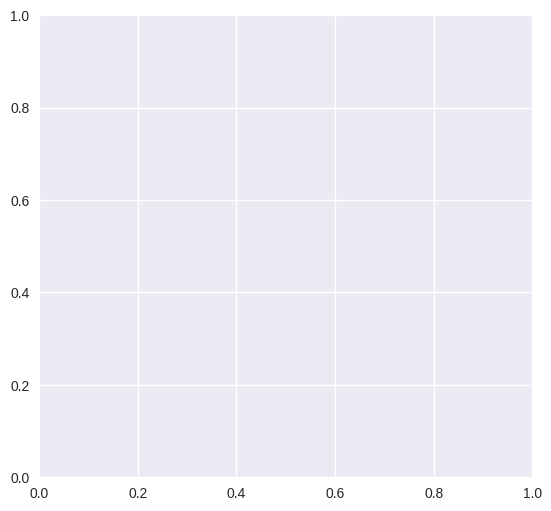

In [11]:
for i, (model, preds) in enumerate(results.items(), 1):
    plt.subplot(2, 2, i)
    sns.residplot(x=preds, y=y_val, lowess=True, line_kws={'color': 'red'})
    plt.title(f'{model} Residuals', fontsize=14)
    plt.xlabel('Predicted Values', fontsize=12)
    plt.ylabel('Residuals', fontsize=12)

plt.tight_layout()
plt.show()

#%% [code]
# Training Curves
plt.figure(figsize=(18, 6))
plt.figure(figsize=(14, 6))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(tabnet_model.history['loss'], label='Train Loss')
if 'val_0_rmse' in tabnet_model.history:  # Check if validation metrics exist
    plt.plot(tabnet_model.history['val_0_rmse'], label='Validation RMSE')
plt.title('TabNet Training Metrics', fontsize=14)
plt.ylabel('Metric Value', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Plot learning rate schedule
plt.subplot(1, 2, 2)
if 'lr' in tabnet_model.history:  # Learning rate history
    plt.plot(tabnet_model.history['lr'], label='Learning Rate', color='green')
    plt.title('Learning Rate Schedule', fontsize=14)
    plt.ylabel('Learning Rate', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
# Neural Network
plt.subplot(1, 2, 1)
plt.plot(nn_history.history['root_mean_squared_error'], label='Train RMSE')
plt.plot(nn_history.history['val_root_mean_squared_error'], label='Val RMSE')
plt.title('Neural Network Training', fontsize=14)
plt.ylabel('RMSE', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend()

# TabNet
plt.subplot(1, 2, 2)
plt.plot(tabnet_model.history['loss'], label='Train Loss')
plt.plot(tabnet_model.history['val_loss'], label='Val Loss')
plt.title('TabNet Training', fontsize=14)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

#%% [markdown]
### 5. Generate Final Predictions
#%%

# Create submissions
for model_name in results.keys():
    if model_name in models:
        preds = np.expm1(models[model_name].predict(X_test_scaled))
    elif model_name == 'Neural Network':
        preds = np.expm1(nn_model.predict(X_test_scaled).flatten())
    elif model_name == 'TabNet':
        preds = np.expm1(tabnet_model.predict(X_test_scaled).flatten())
    
    submission = test[['Batch_ID']].copy()
    submission['T80'] = preds
    submission.to_csv(f"{model_name.lower().replace(' ', '_')}_submission.csv", index=False)